In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import glob
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from matplotlib import colors
import matplotlib.ticker as ticker

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.stats.multitest as smm

In [2]:
# Read in clustering results
cells = pd.read_csv('../data/patient_metacluster_table_patient_updated.csv', index_col=0)
cells.head()

,FileNames,metacluster_1,metacluster_10,metacluster_11,metacluster_12,metacluster_13,metacluster_14,metacluster_15,metacluster_16,metacluster_17,...,Patient_ID,Timepoint,Batch_Control,Reference,Batch_Control_Type,Healthy,Disease,Batch,X7_month_response,X12_month_response
0,P08_C1_D8_Myeloid_Panel,9894.0,0.0,2569.0,30246.0,4.0,1323.0,6842.0,5517.0,82.0,...,P08,C1_D8,C1_D8,False,not_control,Sample,MDS,8,Non_responder,Progression
1,P08_C7_D1_Myeloid_Panel,2411.0,0.0,257.0,2476.0,2.0,429.0,1703.0,754.0,10.0,...,P08,C7_D1,C7_D1,False,not_control,Sample,MDS,8,Non_responder,Progression
2,P08_C7_D22_Myeloid_Panel,454.0,0.0,13.0,114.0,0.0,35.0,207.0,469.0,0.0,...,P08,C7_D22,C7_D22,False,not_control,Sample,MDS,8,Non_responder,Progression
3,P08_SPD_Myeloid_Panel,373.0,0.0,14.0,146.0,2.0,50.0,83.0,320.0,2.0,...,P08,SPD,SPD,False,not_control,Sample,MDS,8,Non_responder,Progression
4,P24_C1_D1_Myeloid_Panel,18476.0,8.0,184.0,2058.0,106.0,180.0,2503.0,525.0,0.0,...,P24,C1_D1,C1_D1,False,not_control,Sample,AML,1,Non_responder,Off_trial_at_month_7


In [3]:
# Delete spare progression sample (there was a second later measurement which was associated with progression)
# Delete sample 61290 006 as the patient went off trial due to participant preference
print(cells.shape)
cells = cells.loc[cells['FileNames'] != 'P02_SPD_Myeloid_Panel',:]
cells = cells.loc[~cells['FileNames'].str.contains('P26'),:]
cells = cells.loc[~cells['FileNames'].str.contains('P27'),:]
cells = cells.loc[~cells['FileNames'].str.contains('P15'),:]
print(cells.shape)
cells['FileNames'] = cells['FileNames'].str.replace('P02_SPD_2_Myeloid_Panel', 'P02_SPD_Myeloid_Panel')
cells['Timepoint'] = cells['Timepoint'].str.replace('SPD_2', 'SPD')
print(cells.shape)

cells = cells.loc[~cells['FileNames'].str.contains('Mobilised'), :]
cells = cells.loc[~cells['FileNames'].str.contains('PBMC_Control'), :]
print(cells.shape)

(118, 52)
(114, 52)
(114, 52)
(114, 52)


In [4]:
# Read in clustering results which were updated on 2025_05_20
cell_type_df = pd.read_csv('../data/myeloid_panel_clusters_2025_05_20.csv')
cluster_dict = dict(zip(cell_type_df['cluster'], cell_type_df['cell_type']))

In [5]:
# Write a dictionary of cell types to cluster numbers
cell_dict = {}
for key, value in cluster_dict.items():
    if value in cell_dict:
        cell_dict[value].append(str(key))
    else:
        cell_dict[value] = [str(key)]
cell_dict

{'HSPCs': ['1', '2'],
 'Aberrant_1': ['3'],
 'Aberrant_2': ['9'],
 'B_cell': ['16'],
 'Monocytes': ['19', '5', '6', '7', '8', '10', '13'],
 'Cytotoxic NK': ['32', '25', '37', '33', '38'],
 'CD38_B_cell': ['14'],
 'T_Cell': ['24', '30', '39'],
 'CD47_low_progenitor': ['15', '20'],
 'CD56_Myeloid': ['11', '23', '35'],
 'Cytokine NK': ['40'],
 'CD66_pos_CD16_neg': ['17'],
 'CD56_pos_T_Cell': ['26', '34', '36'],
 'Myeloid': ['27', '4', '12'],
 'Neutrophils': ['18', '21', '22', '28', '29', '31']}

In [6]:
# Alter the column names to replace the following string so that they are easier to delete
cells.columns = cells.columns.str.replace('metacluster_', '')

In [7]:
# Sum together the columns which belong to specific cell types
for new_col, cols_to_sum in cell_dict.items():
    cells[new_col] = cells[cols_to_sum].sum(axis=1)


# Drop columns with numerical names
cols = [str(i + 1) for i in range(40)]
cells.drop(columns=cols, inplace=True)

del cols

In [8]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx', sheet_name = 'Sheet1', nrows = 40)
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]
patient_info['PID'] = patient_info['PID'].astype(str)

# Create dictionaries so that I can add information to the dataframe such as diagnosis and clinical outcomes

diagnosis_dx = {}
for x, y in zip(patient_info['PID'], patient_info['Diagnosis']):
    diagnosis_dx[x] = y
diagnosis_dx

outcome_C6_dx = {}
for x, y in zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid']):
    outcome_C6_dx[x] = y
outcome_C6_dx 

outcome_C12_dx = {}
for x, y in zip(patient_info['PID'], patient_info['Outcome_C12_CC486']):
    outcome_C12_dx[x] = y


In [9]:
# Use the dictionaries to add clinical outcomes to the dataframe
cells['diagnosis'] = cells['Patient_ID'].str.replace('_', '').map(diagnosis_dx)
cells['outcome_6'] = cells['Patient_ID'].str.replace('_', '').map(outcome_C6_dx)
cells['outcome_12'] = cells['Patient_ID'].str.replace('_', '').map(outcome_C12_dx)
cells = cells.drop(['Date', 'Batch_Control', 'Reference', 'Batch_Control_Type', 'Healthy', 'Disease', 'Batch', 'X7_month_response', 'X12_month_response'], axis =1)


In [10]:
cells

,FileNames,Patient_ID,Timepoint,HSPCs,Aberrant_1,Aberrant_2,B_cell,Monocytes,Cytotoxic NK,CD38_B_cell,...,CD47_low_progenitor,CD56_Myeloid,Cytokine NK,CD66_pos_CD16_neg,CD56_pos_T_Cell,Myeloid,Neutrophils,diagnosis,outcome_6,outcome_12
0,P08_C1_D8_Myeloid_Panel,P08,C1_D8,10701.0,185.0,8514.0,5517.0,538.0,22088.0,1323.0,...,6926.0,3087.0,2710.0,82.0,3227.0,30600.0,5237.0,MDS,non-responder_2,non-responder_2
1,P08_C7_D1_Myeloid_Panel,P08,C7_D1,2545.0,18.0,246.0,754.0,48.0,2875.0,429.0,...,1716.0,330.0,414.0,10.0,686.0,2574.0,708.0,MDS,non-responder_2,non-responder_2
2,P08_C7_D22_Myeloid_Panel,P08,C7_D22,479.0,7.0,29.0,469.0,3.0,2095.0,35.0,...,209.0,14.0,292.0,0.0,317.0,119.0,14.0,MDS,non-responder_2,non-responder_2
3,P08_SPD_Myeloid_Panel,P08,SPD,387.0,1.0,33.0,320.0,6.0,1704.0,50.0,...,88.0,18.0,145.0,2.0,206.0,148.0,13.0,MDS,non-responder_2,non-responder_2
4,P24_C1_D1_Myeloid_Panel,P24,C1_D1,19467.0,78.0,44.0,525.0,2306.0,4533.0,180.0,...,2513.0,208.0,322.0,0.0,1015.0,2176.0,35.0,AML,non-responder_2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,Control_4_Myeloid_Panel,Control_4,Healthy_Control,400.0,482.0,59.0,5774.0,13802.0,4520.0,1089.0,...,2164.0,636.0,1251.0,11.0,3708.0,9334.0,22.0,NaN,NaN,NaN
114,Control_12_Myeloid_Panel,Control_12,Healthy_Control,40.0,12.0,40.0,850.0,210.0,948.0,15.0,...,213.0,356.0,61.0,1.0,457.0,817.0,18.0,NaN,NaN,NaN
115,Control_11_Myeloid_Panel,Control_11,Healthy_Control,258.0,120.0,40.0,4197.0,174.0,1743.0,252.0,...,814.0,409.0,86.0,11.0,3132.0,1972.0,1337.0,NaN,NaN,NaN
116,Control_3_Myeloid_Panel,Control_3,Healthy_Control,812.0,191.0,114.0,35147.0,35409.0,163.0,21.0,...,2436.0,130.0,127.0,18.0,2948.0,7553.0,109.0,NaN,NaN,NaN


In [11]:
# Read in data from Julie. This dataframe contains the patient outcomes and time when a sample was collected 
timepoints = pd.read_excel('../data/MS_flow_outcome_dx_clean_updatedJan24_patient_updated.xlsx')
timepoints['Cycle_day'] = timepoints['Cycle_day'].replace('Progression', 'SPD')
timepoints['PID_Timepoint'] = timepoints['PID'].astype(str) + '_' + timepoints['Cycle_day']
to_keep = ['Cycle_day', 'Day_since_C1D1', 'Day_since_scr', 'PID_Timepoint']
timepoints = timepoints.loc[:,timepoints.columns.isin(to_keep)]
cells['pid_timepoint'] = cells['Patient_ID'].str.replace('_', '') + '_' + cells['Timepoint'].str.replace('_', '')

cells = pd.merge(cells, timepoints, left_on='pid_timepoint', right_on= 'PID_Timepoint', how = 'left')

In [12]:
# Add a new column called best response to the df
best_response = ['responder' if x == 'responder_1' or y == 'responder_1' else 'non_responder' for x, y in zip(cells['outcome_6'], cells['outcome_12'])]
cells['best_response'] = best_response

del best_response

In [13]:
# Calculate the total number of cells and total number of cells which are CD34 neg
cells['total'] = cells.loc[:, 'HSPCs':'Neutrophils'].sum(axis=1)
cells['total_cd34_neg'] = cells.loc[:, 'Aberrant_1':'Neutrophils'].sum(axis=1)


In [14]:
# Create a list of columns to correct for the percent of CD45+ and CD34- cells
selected_columns = [col for col in cells.columns[4:18]]
selected_columns

['Aberrant_1',
 'Aberrant_2',
 'B_cell',
 'Monocytes',
 'Cytotoxic NK',
 'CD38_B_cell',
 'T_Cell',
 'CD47_low_progenitor',
 'CD56_Myeloid',
 'Cytokine NK',
 'CD66_pos_CD16_neg',
 'CD56_pos_T_Cell',
 'Myeloid',
 'Neutrophils']

In [15]:
# Calculate a percentage of cells as a percent of CD45 pos CD34 negative
cells[selected_columns] = cells[selected_columns].div(cells['total_cd34_neg'], axis = 0) * 100

# Calculate the percentage of HSPCs as a percent of CD45+
cells['HSPCs'] = cells['HSPCs'].div(cells['total'], axis = 0) * 100

In [16]:
# Find samples with a C7D22 but not a C7D1
pid_tp = []
for i in cells['Patient_ID'].unique():
    z = cells.loc[cells['Patient_ID'] == i, :]
    if ('C7_D22' in z['Timepoint'].to_list()) and ('C7_D1' not in z['Timepoint'].to_list()):
        pid_tp.append((str(i.replace('_', '')) + '_C7D22'))

In [17]:
# Filter the df for the samples acquired at C1 D1 and C7 D1 or a C7D22
print(cells.shape)
cells = cells.loc[(cells['Timepoint'] == 'C1_D1') | (cells['Timepoint'] == 'C7_D1') | (cells['PID_Timepoint'].isin(pid_tp)), :]
print(cells.shape)

(114, 29)
(41, 29)


In [18]:
import re

def text_to_int(text_obj):
    # Get the text content from the text object
    text_content = text_obj.get_text()
    
    # Replace Unicode minus sign (U+2212) with ASCII minus sign
    text_content = text_content.replace('\u2212', '-')
    
    # Remove any non-digit characters, but keep the minus sign at the beginning if present
    cleaned_text = re.sub(r'^-?\D*(-?\d+).*$', r'\1', text_content)
    
    try:
        # Try to convert the cleaned string to an integer
        return int(cleaned_text)
    except ValueError:
        print(f"Could not convert '{text_content}' to an integer.")
        return None


In [19]:
# Replace empty strings in the dataframe and add another column as an integer so that 
# I can perfom some statistical analysis
cells.columns = cells.columns.str.replace(' ', '_')
cells['time_point'] = ((cells['Cycle_day'] == 'C7D1')| (cells['Cycle_day'] == 'C7D22')).astype(int)

In [20]:
# Create a function to run the mixed-effects model for a single column
def run_mixed_model(df, column):
    model_data = df[['Patient_ID', 'time_point', column]].copy()
    model_data.columns = ['Patient_ID', 'time_point', 'value']
    
    # Fit a linear mixed-effects model
    model = smf.mixedlm('value ~ time_point', model_data, groups=model_data['Patient_ID'])
    result = model.fit()
    
    return result

# Run the analysis for each relevant column
r_results = {}
nr_results = {}
for i in cells['best_response'].unique():
    a = cells.loc[cells['best_response'] == i, :]
    for column in a.columns[3:18]:  # Adjust the range as needed
        print(f"Analyzing {column}:")
        result = run_mixed_model(a, column)
        print(result.summary())
        print('\n')
        if i == 'responder':
            r_results[column] = result
        elif i == 'non_responder':
            nr_results[column] = result

Analyzing HSPCs:
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 12      Method:             REML    
No. Groups:       8       Scale:              42.1594 
Min. group size:  1       Log-Likelihood:     -38.8354
Max. group size:  2       Converged:          Yes     
Mean group size:  1.5                                 
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept   13.378    3.922  3.411 0.001  5.690 21.066
time_point  -1.339    4.310 -0.311 0.756 -9.787  7.109
Group Var   70.765   13.213                           



Analyzing Aberrant_1:
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 12      Method:             REML    
No. Groups:       8       Scale:              0.2837  
Min. group size:  1       Log-Likelihood:

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.

        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 12      Method:             REML    
No. Groups:       8       Scale:              14.5304 
Min. group size:  1       Log-Likelihood:     -35.9757
Max. group size:  2       Converged:          Yes     
Mean group size:  1.5                                 
------------------------------------------------------
             Coef.  Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------
Intercept     3.025    3.155 0.959 0.338 -3.159  9.208
time_point    5.366    2.588 2.073 0.038  0.293 10.439
Group Var    60.982   16.155                          



Analyzing Cytokine_NK:
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 12      Method:             REML    
No. Groups:       8       Scale:              19.6900 
Min. group size:  1       Log-Likelihood:     -31.7851
Ma

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [21]:
# Add the p-values to responder and non-responder dictionaries
r_pval_dict = {}
nr_pval_dict = {}
for i in r_results:
    r_pval_dict[i] = r_results[i].pvalues[1]
for i in nr_results:
    nr_pval_dict[i] = nr_results[i].pvalues[1]
    

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6449/674437675.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_pval_dict[i] = r_results[i].pvalues[1]
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6449/674437675.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_pval_dict[i] = r_results[i].pvalues[1]
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6449/674437675.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position

In [22]:
# Update the p-values in each dictionary to account for multiple testing hypothesis
def correct_p_values(dict1, dict2):
    # Combine p-values from both dictionaries
    all_p_values = list(dict1.values()) + list(dict2.values())
    
    # Perform FDR correction
    rejected, corrected_p_values, _, _ = smm.multipletests(all_p_values, method='fdr_bh')
    
    # Split the corrected p-values back into two lists
    split_index = len(dict1)
    corrected_dict1 = corrected_p_values[:split_index]
    corrected_dict2 = corrected_p_values[split_index:]
    
    # Update the original dictionaries with corrected p-values
    for (key, _), corrected_p in zip(dict1.items(), corrected_dict1):
        dict1[key] = corrected_p
    
    for (key, _), corrected_p in zip(dict2.items(), corrected_dict2):
        dict2[key] = corrected_p
    
    return dict1, dict2

# Apply the correction
r_pval_dict1, nr_pval_dict1 = correct_p_values(r_pval_dict, nr_pval_dict)

# Print the results
print("Corrected dict1:", r_pval_dict1)
print("Corrected dict2:", nr_pval_dict1)


Corrected dict1: {'HSPCs': 0.3759522436468192, 'Aberrant_1': 0.08548070843804827, 'Aberrant_2': 0.18781325432003124, 'B_cell': 0.6693983995175438, 'Monocytes': 0.0019067387349359184, 'Cytotoxic_NK': 0.012960238953939867, 'CD38_B_cell': 0.3363227590222224, 'T_Cell': 0.00031922372129723666, 'CD47_low_progenitor': 0.3363227590222224, 'CD56_Myeloid': 0.16569287232959667, 'Cytokine_NK': 0.2664108939199007, 'CD66_pos_CD16_neg': 0.1748264562097229, 'CD56_pos_T_Cell': 0.009300917735610459, 'Myeloid': 0.0013243239070202877, 'Neutrophils': 0.0005974681718056716}
Corrected dict2: {'HSPCs': 0.8100624162429861, 'Aberrant_1': 0.1748264562097229, 'Aberrant_2': 0.05216623443606104, 'B_cell': 0.27246232096673895, 'Monocytes': 0.1748264562097229, 'Cytotoxic_NK': 0.577774707415853, 'CD38_B_cell': 0.16569287232959667, 'T_Cell': 0.5241490860096204, 'CD47_low_progenitor': 0.3607200146311854, 'CD56_Myeloid': 0.11446370692565064, 'Cytokine_NK': 0.3607200146311854, 'CD66_pos_CD16_neg': 0.3607200146311854, 'CD5

In [23]:
def add_significance_stars(ax, x, y, p_value, is_responder, fontsize=8):
    # Map p-value thresholds to stars
    thresholds = [(0.0001, '****'), (0.001, '***'), (0.01, '**'), (0.05, '*')]
    
    stars = next((s for threshold, s in thresholds if p_value < threshold), None)
    if not stars:
        return
    
    y_limit = ax.get_ylim()[1]
    bar_width = 0.35
    offset = 5.08  # Distance between line and star center
    
    if is_responder:
        # For responders (top): line first, then stars above it
        line_y = y_limit * 0.80
        star_y = line_y + offset
    else:
        # For non-responders (bottom): line first, then stars below it
        line_y = y_limit * -0.80
        star_y = line_y - (offset * 2.5)
    
    # Add horizontal line
    color = 'black' #if is_responder else '#fe9003'
    ax.hlines(y=line_y, xmin=x - bar_width/2, xmax=x + bar_width/2, 
              colors=color, linewidth=0.8, linestyle='-')
    
    # Add the stars with centered alignment for symmetry
    ax.text(x, star_y, stars, ha='center', va='center', fontsize=fontsize)

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6449/2281869564.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([100, 50, 0, 50, 100], fontsize=7)


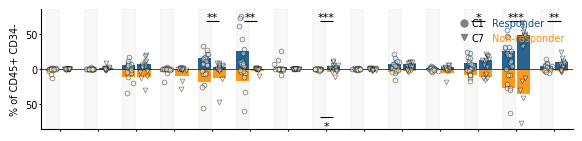

In [24]:
#Set up figure and plot parameters
fig, ax = plt.subplots(figsize=(6.69 * (13/14), 2))
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 'truetype'

# Define styling
colors = {'non_responder': '#fe9003', 'responder': '#115284'}

dot_colors = {'non_responder': '#FFF3CD', 'responder':  '#D0E8F5'}

markers = {'C1_D1': 'o', 'C7_D1': 'v'}
alphas = {'C1_D1': 1.0, 'C7_D1': 1.0}

# Categories and setup
categories = ['Aberrant_1', 'Aberrant_2', 'CD47_low_progenitor', 'CD56_Myeloid',
 'Myeloid', 'Monocytes','CD66_pos_CD16_neg',
 'Neutrophils','CD38_B_cell','B_cell','Cytokine_NK',
 'Cytotoxic_NK','T_Cell', 'CD56_pos_T_Cell']

x_positions = np.arange(len(categories))
bar_width = 0.35
mean_values = cells.groupby(['best_response', 'Timepoint'])[categories].mean()

time_offsets = {'C1_D1': -bar_width/2 - 0.025, 'C7_D1': bar_width/2 + 0.025}

y_max = cells[categories].max().max() * 1.1
y_min = cells[categories].max().max() * -1.1
ax.set_ylim(y_min, y_max)

# Plot bars for each outcome and time 
for outcome in ['responder', 'non_responder']:
    multiplier = 1 if outcome == 'responder' else -1
    #y_min, y_max = ax.get_ylim()
    ax.bar(x_positions + time_offsets['C1_D1'], y_max * multiplier, bar_width,
           facecolor='lightgrey', edgecolor='lightgrey', alpha=0.15)#,
           #hatch='xxxxxx', linewidth=0.5, zorder=1)

    for time, offset in time_offsets.items():
        values = mean_values.loc[outcome, time]
        ax.bar(x_positions + offset, values * multiplier, bar_width,
               facecolor=colors[outcome], edgecolor=None,
               alpha=0.9, label=f'{outcome} - {time}')

        for i, category in enumerate(categories):
            subset = cells[(cells['best_response'] == outcome) & (cells['Timepoint'] == time)]
            x_jitter = np.random.normal(0, 0.05, size=len(subset))  # x jitter for vertical chart
            ax.scatter(x_positions[i] + offset + x_jitter,          # x = category position
                       subset[category] * multiplier,                # y = value
                       marker=markers[time],
                       facecolor= dot_colors[outcome],
                       edgecolor='black', linewidth=0.5,
                       alpha=0.5, s=12, zorder=3)
            
# # Add gridlines
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)


# # Format axes
ax.tick_params(axis='both', labelsize=7, pad=1, length=1.5)
ax.set_xticks(range(14))
ax.set_xticklabels([], rotation=90, fontsize=7)
ax.set_yticklabels([100, 50, 0, 50, 100], fontsize=7)
ax.set_xlim(-0.5, 13.5)
ax.set_ylabel('% of CD45+ CD34-', fontsize=7)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# # Add legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
               markeredgewidth=1, markeredgecolor='grey', markersize=5, label='C1'),
    plt.Line2D([0], [0], marker='v', color='w', markerfacecolor='grey',
               markeredgewidth=1, markeredgecolor='grey', markersize=5, label='C7'),
    plt.Line2D([0], [0], linestyle='', color='#115284', label='Responder'),
    plt.Line2D([0], [0], linestyle='', color='#fe9003', label='Non-responder')
]
ax.legend(handles=legend_elements, ncol=2, columnspacing=-1, handletextpad=-0.25,
          loc='upper right', labelcolor=['black', 'black', '#115284', '#fe9003'],
          fontsize=7, frameon=False)

# # Add significance stars
y_min, y_max = ax.get_ylim()
for outcome in ['responder', 'non_responder']:
    for i, category in enumerate(categories):
        p_value = r_pval_dict1[category] if outcome == 'responder' else nr_pval_dict1[category]
        add_significance_stars(ax, x_positions[i], 0, p_value, outcome == 'responder')

# # # Save figure
fig.set_size_inches(6.6 * (12/14), 1.25)
fig.tight_layout(pad=0.1)
fig.savefig('../results/cell_types_graphs_v3.pdf', bbox_inches='tight', pad_inches=0.01, dpi=600)

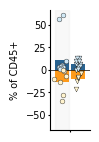

In [26]:
# Set up figure and plot parameters
fig, ax = plt.subplots(figsize=(5.69 * (1.6/14), 2))
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 'truetype'

# Define styling
colors = {'non_responder': '#fe9003', 'responder': '#115284'}

colors1 = {'non_responder': '#FFF3CD', 'responder':  '#D0E8F5'}

markers = {'C1_D1': 'o', 'C7_D1': 'v'}
alphas = {'C1_D1': 1.0, 'C7_D1': 1.0}

# Categories and setup
categories = ['HSPCs']
x_positions = np.arange(len(categories))
bar_width = 0.35
mean_values = cells.groupby(['best_response', 'Timepoint'])[categories].mean()

# Plot bars and scatter points
max_val = cells[categories].max().max()

y_max = cells[categories].max().max() * 1.1
y_min = cells[categories].max().max() * -1.1
ax.set_ylim(y_min, y_max)

for outcome in ['responder', 'non_responder']:
    multiplier = 1 if outcome == 'responder' else -1

    # Hatched background only for C1D1
    ax.bar(x_positions + time_offsets['C1_D1'], # max_val * multiplier, bar_width,
           y_max * multiplier, bar_width,
           facecolor='lightgrey', edgecolor='lightgrey', alpha=0.15)#, 
           #hatch='xxxxxx', linewidth=0.5, zorder=1)

    for time, offset in time_offsets.items():
        values = mean_values.loc[outcome, time]
        ax.bar(x_positions + offset, values * multiplier, bar_width,
               facecolor=colors[outcome], edgecolor=None,
               alpha=0.9, label=f'{outcome} - {time}')

        for i, category in enumerate(categories):
            subset = cells[(cells['best_response'] == outcome) & (cells['Timepoint'] == time)]
            x_jitter = np.random.normal(0, 0.05, size=len(subset))  # x jitter for vertical chart
            ax.scatter(x_positions[i] + offset + x_jitter,          # x = category position
                       subset[category] * multiplier,                # y = value
                       marker=markers[time],
                       facecolor= colors1[outcome],
                       edgecolor='black', linewidth=0.25,
                       alpha=1, s=12, zorder=3)
                
# Add gridline and format axes
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylim(bottom=y_min, top=y_max)
ax.tick_params(axis='both', labelsize=7, pad=1, length=1.5)
ax.set_xticks(range(len(categories)))
ax.set_xticklabels([], rotation=90, fontsize=7)
ax.set_xlim(-0.5, 0.5)
ax.set_ylabel('% of CD45+', fontsize=7)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Add significance stars
for i, category in enumerate(categories):
    for outcome in ['responder', 'non_responder']:
        p_value = r_pval_dict1[category] if outcome == 'responder' else nr_pval_dict1[category]
        add_significance_stars(ax, x_positions[i], 0, p_value, outcome == 'responder')

# Save figure
fig.set_size_inches(6.6 * 1.5/12, 1.25) # strange label to match the 
fig.tight_layout(pad=0.1)
fig.savefig('../results/stem_types_graphs2.pdf', bbox_inches='tight', pad_inches=0.01, dpi=300)